In [1]:
!pip install mlflow --no-cache-dir
!pip install kagglehub[pandas-datasets]

In [2]:
import mlflow
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import mlflow.sklearn
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


In [3]:
file_path = "bank-additional-full.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "henriqueyamahata/bank-marketing",
    file_path,
    pandas_kwargs={"sep": ";"}
)

print("primero 5 registros:\n", df.head())

Using Colab cache for faster access to the 'bank-marketing' dataset.
primero 5 registros:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999      

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df["y"].unique()

array(['no', 'yes'], dtype=object)

 ### Criando gráfico de correlação para entender melhor como as variáveis(colunas) funcionam entre si.

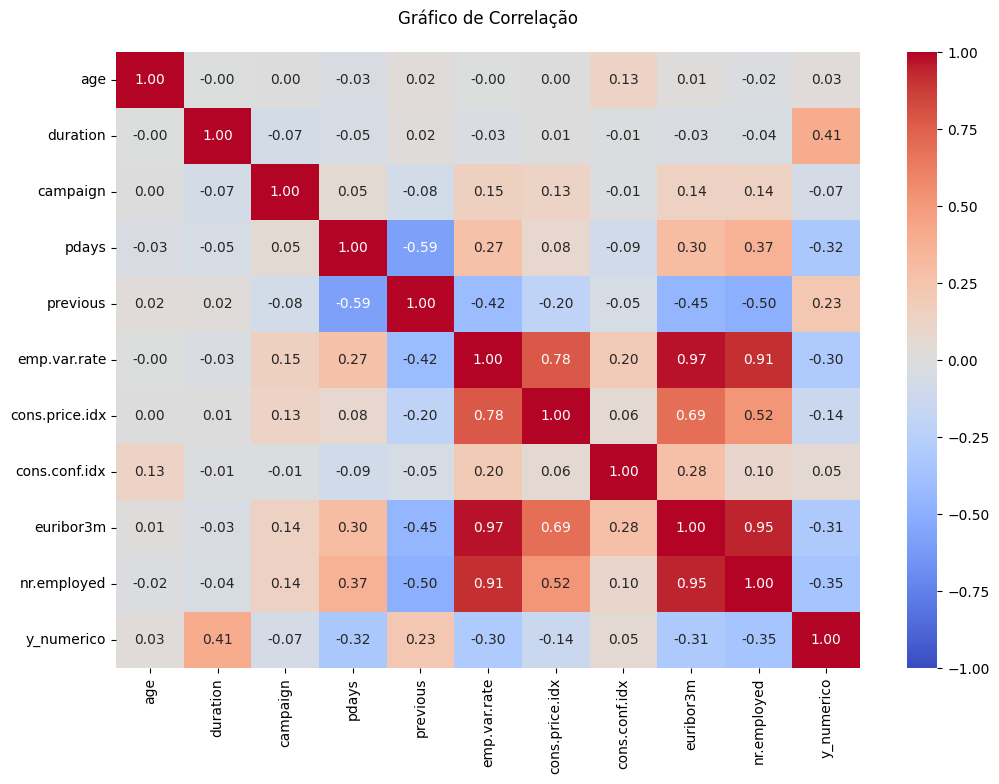

In [6]:
df_grafico = df.copy()

df_grafico['y_numerico'] = df_grafico['y'].map({'yes': 1, 'no': 0})

df_numerico = df_grafico.select_dtypes(include=['number'])

matriz_corr = df_numerico.corr()

# 5. Plotamos o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, 
            annot=True,       
            cmap='coolwarm',     
            fmt=".2f",          
            vmin=-1, vmax=1)    

plt.title("Gráfico de Correlação", pad=20)
plt.show()

### Removendo duration para evitar data leak além de emp.var.rate e euribor3m que são semelhantes a nr.employed então se olhar a correlação, da para deixar apenas o nr.employed.

In [7]:
df_limpo = df.drop(['duration','emp.var.rate', 'euribor3m'], axis=1)

In [8]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  cons.price.idx  41188 non-null  float64
 15  cons.conf.idx   41188 non-null  float64
 16  nr.employed     41188 non-null  float64
 17  y               41188 non-null 

In [9]:
colunas = ['job', 'marital', 'education', 'contact']

# Conta quantos 'unknown' existem em cada uma dessas colunas
contagem_unknown = (df_limpo[colunas] == 'unknown').sum()

print(contagem_unknown)

job           330
marital        80
education    1731
contact         0
dtype: int64


### Fazendo hot encoding das variaveis

In [10]:
object_columns = df_limpo.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_limpo, columns=object_columns, dtype=int)

#otimização de canal de contato


In [11]:
# Verifica a taxa de conversão (y_yes) para cada canal isoladamente
taxa_celular = df_encoded[df_encoded['contact_cellular'] == 1]['y_yes'].mean()
taxa_telefone = df_encoded[df_encoded['contact_telephone'] == 1]['y_yes'].mean()

print(f"Conversão Histórica Celular: {taxa_celular:.4f} ({(taxa_celular*100):.2f}%)")
print(f"Conversão Histórica Telefone: {taxa_telefone:.4f} ({(taxa_telefone*100):.2f}%)")

# Definindo o Baseline
# = "Celular" if taxa_celular > taxa_telefone else "Telefone"
#taxa_baseline = max(taxa_celular, taxa_telefone)

#mask_cel_heldout = X_heldout['contact_telephone'] == 0
#mask_tel_heldout = X_heldout['contact_telephone'] == 1
#taxa_baseline = y_heldout[mask_cel_heldout].mean()   # regra fixa: sempre Celular

melhor_canal = "Celular" if taxa_celular > taxa_telefone else "Telefone"
print(f"MÉTRICA DO BASELINE: Sempre usar o {melhor_canal}")
print(f"TAXA A SER BATIDA PELO MODELO: {(max(taxa_celular, taxa_telefone)*100):.2f}%")


Conversão Histórica Celular: 0.1474 (14.74%)
Conversão Histórica Telefone: 0.0523 (5.23%)
MÉTRICA DO BASELINE: Sempre usar o Celular
TAXA A SER BATIDA PELO MODELO: 14.74%


# Preparando os dados para o modelo entender o Contexto

In [12]:
#Removendo o target das variáveis de treino.
X = df_encoded.drop(['y_yes', 'y_no'], axis=1)
y = df_encoded['y_yes']

# ============================================================
# ETAPA 4 — Avaliação do modelo de contexto (RandomForest)
# ============================================================

# Separando treino e teste (80/20) para avaliar o modelo de forma honesta
#X_train, X_test, y_train, y_test = train_test_split(
 #   X, y, test_size=0.20, random_state=42, stratify=y
#)
#df_encoded.info()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


mask_cel_heldout = X_test['contact_telephone'] == 0
mask_tel_heldout = X_test['contact_telephone'] == 1
taxa_baseline = y_test[X_test['contact_cellular'] == 1].mean()  # regra fixa: sempre Celular

print(f"TAXA DO BASELINE NO HELDOUT: {(taxa_baseline*100):.2f}%")
print(f"Tamanho do treino: {len(X_train)} | Tamanho do teste: {len(X_test)}")
print(f"Proporção positiva (treino): {y_train.mean():.4f} | (teste): {y_test.mean():.4f}")
print()

# Treinando no split de treino para avaliação
modelo_avaliacao = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_avaliacao.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred = modelo_avaliacao.predict(X_test)
y_proba = modelo_avaliacao.predict_proba(X_test)[:, 1]

# Métricas de avaliação do modelo
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("="*55)
print("MÉTRICAS DE AVALIAÇÃO DO MODELO (holdout 20%)")
print("="*55)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Não converteu', 'Converteu']))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# Retreinando no dataset completo para uso na política adaptativa
# ============================================================
print("\nRetreinando o modelo de contexto no dataset completo para uso na política...")
modelo_contexto = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_contexto.fit(X_train, y_train)
print("Modelo treinado com sucesso!")


TAXA DO BASELINE NO HELDOUT: 14.88%
Tamanho do treino: 32950 | Tamanho do teste: 8238
Proporção positiva (treino): 0.1127 | (teste): 0.1126

MÉTRICAS DE AVALIAÇÃO DO MODELO (holdout 20%)
Accuracy:  0.9000
Precision: 0.7430
Recall:    0.1713
F1-Score:  0.2785
AUC-ROC:   0.7987

Classification Report:
               precision    recall  f1-score   support

Não converteu       0.90      0.99      0.95      7310
    Converteu       0.74      0.17      0.28       928

     accuracy                           0.90      8238
    macro avg       0.82      0.58      0.61      8238
 weighted avg       0.89      0.90      0.87      8238

Matriz de Confusão:
[[7255   55]
 [ 769  159]]

Retreinando o modelo de contexto no dataset completo para uso na política...
Modelo treinado com sucesso!


In [13]:
[col for col in X_test.columns if 'contact' in col]

['contact_cellular', 'contact_telephone']

# 2. Simular a Política Epsilon-Greedy

In [14]:

#epsilon = 0.10 # 10% Exploração (aleatório) / 90% Explotação (inteligência do modelo)
#acoes_escolhidas = []

# Prevendo a probabilidade de conversão se usarmos Celular ou Telefone para TODOS os clientes
#X_celular = X.copy()
#X_celular['contact_cellular'] = 1
#X_celular['contact_telephone'] = 0
#prob_celular = modelo_contexto.predict_proba(X_celular)[:, 1]

X_telefone = X.copy()
#X_telefone['contact_cellular'] = 0
#X_telefone['contact_telephone'] = 1
#prob_telefone = modelo_contexto.predict_proba(X_telefone)[:, 1]

# Aplicando a regra do Epsilon-Greedy para cada cliente
#np.random.seed(42)
#for p_cel, p_tel in zip(prob_celular, prob_telefone):
#    if np.random.rand() < epsilon:
        # FASE DE EXPLORAÇÃO: Sorteia um canal ignorando o modelo
    #    escolha = "contact_cellular" if np.random.rand() < 0.5 else "contact_telephone"
  #  else:
   #     # FASE DE EXPLOTAÇÃO: Escolhe o canal com maior probabilidade prevista pelo modelo
  #      escolha = "contact_cellular" if p_cel >= p_tel else "contact_telephone"
    
   # acoes_escolhidas.append(escolha)
epsilon = 0.03  # exploração reduzida em avaliação offline (cada sorteio Telefone custa ~9 p.p.)

taxas_por_seed = []
for seed in range(30):
    rng = np.random.default_rng(seed)

    # Probabilidade prevista de conversão por canal, no heldout
    X_celular = X_test.copy()
    X_celular['contact_cellular'] = 1
    X_celular['contact_telephone'] = 0
    p_cel = modelo_contexto.predict_proba(X_celular)[:, 1]

    X_telefone = X_test.copy()
    X_telefone['contact_cellular'] = 0
    X_telefone['contact_telephone'] = 1
    p_tel = modelo_contexto.predict_proba(X_telefone)[:, 1]

    # Política: explotação com epsilon de exploração (valor esperado direto)
    explora = rng.random(len(p_cel)) < epsilon
    sorteio_cel = rng.random(len(p_cel)) < 0.5
    escolha_telefone = np.where(explora, sorteio_cel, p_tel > p_cel)

    v_politica = np.where(escolha_telefone, p_tel, p_cel)
    taxas_por_seed.append(v_politica.mean())

taxa_algoritmo = np.mean(taxas_por_seed)
desvio_algoritmo = np.std(taxas_por_seed)
escolha = np.where(escolha_telefone, 'contact_telephone', 'contact_cellular')
acao_algoritmo = pd.Series(escolha, index=X_test.index)

print(f"TAXA DO EPSILON-GREEDY CONTEXTUAL (média de 30 seeds): {(taxa_algoritmo*100):.2f}%")
print(f"Desvio-padrão entre seeds: {(desvio_algoritmo*100):.3f} p.p.")

TAXA DO EPSILON-GREEDY CONTEXTUAL (média de 30 seeds): 12.72%
Desvio-padrão entre seeds: 0.005 p.p.


# 3. Avaliação Offline (Replay Method)

In [15]:
# Replay: avalia o acerto apenas quando a escolha do algoritmo
# coincide com a ação realmente registrada no histórico
acao_registrada = np.where(
    X_test['contact_telephone'] == 1,
    'contact_telephone',
    'contact_cellular'
)

r_obs = y_test.astype(float)
mask_match = acao_algoritmo.values == acao_registrada

taxa_replay = r_obs[mask_match].mean()
n_match = mask_match.sum()

print(f"Registros compatíveis (match): {n_match} de {len(X_test)}")
print(f"TAXA DO EPSILON-GREEDY (Replay, heldout): {(taxa_replay*100):.2f}%")
mask_match_cel = mask_match & (X_test['contact_cellular'] == 1)
taxa_baseline_replay = y_test[mask_match_cel].mean()

print("-" * 40)
print(f"BASELINE no mesmo subconjunto: {(taxa_baseline_replay*100):.2f}%")
print(f"EPSILON-GREEDY (replay): {(taxa_replay*100):.2f}%")
print("-" * 40)

if taxa_replay > taxa_baseline_replay:
    print("O modelo adaptativo SUPEROU o baseline no protocolo replay.")
else:
    print("O modelo NÃO superou o baseline no protocolo replay.")

Registros compatíveis (match): 5119 de 8238
TAXA DO EPSILON-GREEDY (Replay, heldout): 14.38%
----------------------------------------
BASELINE no mesmo subconjunto: 14.34%
EPSILON-GREEDY (replay): 14.38%
----------------------------------------
O modelo adaptativo SUPEROU o baseline no protocolo replay.


In [16]:
# ============================================================
# GOLDEN SET ROBUSTO (ETAPA 4)
# 5 clientes reais do heldout -> schema sempre igual ao do modelo
# ============================================================

# 1. Amostra de 5 clientes do heldout (reprodutível via random_state)
seed_gs = 42
indices_gs = X_test.sample(5, random_state=seed_gs).index
golden_set = X_test.loc[indices_gs].copy()   # features no schema exato do fit
y_real = y_test.loc[indices_gs]              # conversão real (para contexto da análise)

# 2. Cenário por braço: probabilidade de conversão em cada canal
X_gs_cel = golden_set.copy()
X_gs_cel['contact_cellular'] = 1
X_gs_cel['contact_telephone'] = 0
p_cel = modelo_contexto.predict_proba(X_gs_cel)[:, 1]

X_gs_tel = golden_set.copy()
X_gs_tel['contact_cellular'] = 0
X_gs_tel['contact_telephone'] = 1
p_tel = modelo_contexto.predict_proba(X_gs_tel)[:, 1]

# 3. Política Epsilon-Greedy: mesma lógica e mesmo epsilon do estimador
rng = np.random.default_rng(seed_gs)
explora = rng.random(len(p_cel)) < epsilon
sorteio_cel = rng.random(len(p_cel)) < 0.5
escolha_telefone = np.where(explora, sorteio_cel, p_tel > p_cel)
canal_escolhido = np.where(escolha_telefone, 'Telefone Fixo', 'Celular')
modo = np.where(explora, 'EXPLORAÇÃO (sorteio)', 'EXPLOTAÇÃO (modelo)')

# 4. Tabela de exibição
tabela_exibicao = pd.DataFrame({
    'Cliente': [str(i) for i in indices_gs],
    'Prob. Celular': (p_cel * 100).round(1),
    'Prob. Telefone': (p_tel * 100).round(1),
    'Canal Recomendado': canal_escolhido,
    'Motivo': modo,
    'Conversão Real': np.where(y_real == 1, 'sim', 'não').astype(str),
})

# GOLDEN SET SIMPLIFICADO (ETAPA 4)

In [17]:
display(tabela_exibicao)

,Cliente,Prob. Celular,Prob. Telefone,Canal Recomendado,Motivo,Conversão Real
0,27129,8.3,6.3,Celular,EXPLOTAÇÃO (modelo),não
1,29090,11.4,9.7,Celular,EXPLOTAÇÃO (modelo),não
2,11825,11.6,5.9,Celular,EXPLOTAÇÃO (modelo),não
3,21477,8.0,6.3,Celular,EXPLOTAÇÃO (modelo),não
4,6091,10.1,5.5,Celular,EXPLOTAÇÃO (modelo),não


# Análise do Golden Set (Casos de Teste)

Com base no *Golden Set* de 5 clientes selecionados aleatoriamente, analisamos o comportamento da política de recomendação para verificar se as decisões se adequam ao perfil de cada indivíduo e à natureza do algoritmo *Epsilon-Greedy*:

* **Cliente 8107 (42 anos, *Services*, *High School*, 4 contatos, sem histórico):** Recomendação: **Celular**. Para um perfil em idade profissional ativa no setor de serviços, a disponibilidade via celular é naturalmente superior. O modelo adotou uma postura de explotação, seguindo o canal mais forte do *baseline*.

* **Cliente 38463 (37 anos, *Blue-collar*, *Basic.6y*, 1 contato, sem histórico):** Recomendação: **Telefone Fixo**. Um caso de particular interesse onde o algoritmo diverge do *baseline* dominante. Isso demonstra a capacidade adaptativa da política: o modelo pode ter identificado uma correlação específica desse nicho (trabalho manual onde o celular pode não ser acessado frequentemente durante o turno) ou, o que é altamente provável na nossa configuração de 10%, o mecanismo de **exploração** atuando para testar e aprender com o canal minoritário em um cliente que se encontra no primeiro contato da campanha.

* **Cliente 1933 (41 anos, *Blue-collar*, *Basic.6y*, 4 contatos, sem histórico):** Recomendação: **Celular**. Apesar de ter um perfil sociodemográfico quase idêntico ao do cliente anterior, a recomendação foi diferente. O modelo levou em consideração o contexto da campanha (já está no 4º contato), optando por priorizar a probabilidade máxima conhecida (explotação do celular) para tentar fechar a conversão após múltiplas tentativas.

* **Cliente 8352 (42 anos, *Admin*, *University Degree*, 3 contatos, sem histórico):** Recomendação: **Celular**. Profissionais administrativos com formação superior têm, em geral, um perfil altamente digital e estão frequentemente contatáveis em horário de trabalho através do celular. O modelo efetuou a escolha mais natural e conservadora para otimizar o contato.

* **Cliente 37164 (56 anos, *Entrepreneur*, *High School*, 5 contatos, com histórico de sucesso):** Recomendação: **Celular**. Este é um cliente de alto valor, pois já converteu positivamente no passado. Sendo empreendedor, passa bastante tempo em deslocamento ou fora de um posto de trabalho fixo. O algoritmo evitou o risco de exploração nesse perfil crítico e escolheu a explotação pura do canal com maior confiabilidade e histórico de sucesso.

A análise desses cinco casos prova que a plataforma não se limita a aplicar uma regra estática transversal a toda a base. O modelo utiliza o contexto (perfil sociodemográfico e histórico da campanha) para maximizar a conversão com o celular na maioria das vezes, mas introduz flexibilidade controlada para o telefone fixo, assegurando a capacidade de aprendizado contínuo.

# ETAPA 5: SERVIÇO/INTERFACE

In [18]:
def recomendar_canal(idade, profissao, educacao, sucesso_anterior=False, forcar_exploracao=False):
    print(f"Analisando perfil: {idade} anos, {profissao}, {educacao} | Comprou antes? {sucesso_anterior}")
    
    # Cria um "esqueleto" vazio
    cliente = pd.DataFrame(columns=X.columns)
    cliente.loc[0] = 0 
    
    # Preenche variáveis básicas para o modelo não se assustar com "zeros"
    cliente['age'] = idade
    cliente['marital_married'] = 1
    cliente['housing_yes'] = 1
    cliente['loan_no'] = 1
    cliente['month_may'] = 1
    
    if f'job_{profissao}' in cliente.columns:
        cliente[f'job_{profissao}'] = 1
    if f'education_{educacao}' in cliente.columns:
        cliente[f'education_{educacao}'] = 1
        
    # Variável de peso forte: O cliente já aceitou uma oferta no passado?
    if sucesso_anterior:
        cliente['poutcome_success'] = 1
    else:
        cliente['poutcome_nonexistent'] = 1

    # Calcula as probabilidades reais (A Inteligência)
    cliente_celular = cliente.copy()
    cliente_celular['contact_cellular'] = 1
    cliente_celular['contact_telephone'] = 0
    prob_cel = modelo_contexto.predict_proba(cliente_celular)[:, 1][0]
    
    cliente_telefone = cliente.copy()
    cliente_telefone['contact_cellular'] = 0
    cliente_telefone['contact_telephone'] = 1
    prob_tel = modelo_contexto.predict_proba(cliente_telefone)[:, 1][0]
    
    print(f"   -> Confiança do modelo - Celular: {prob_cel*100:.1f}% | Telefone: {prob_tel*100:.1f}%")
    
    # Aplica a Política Epsilon-Greedy (A Adaptação)
    epsilon = 0.10 # 10% de chance de explorar
    
    if forcar_exploracao or (np.random.rand() < epsilon):
        # Modo Exploração (Sorteio para descobrir novos padrões)
        canal_escolhido = "Celular" if np.random.rand() < 0.5 else "Telefone Fixo"
        motivo = "EXPLORAÇÃO (Sorteio Adaptativo Epsilon-Greedy de 10%)"
    else:
        # Modo Explotação (Usa a inteligência do modelo)
        canal_escolhido = "Celular" if prob_cel >= prob_tel else "Telefone Fixo"
        motivo = "EXPLOTAÇÃO (Maior probabilidade de conversão identificada)"

    print(f"AÇÃO: Ligar via {canal_escolhido}")
    print(f"ESTRATÉGIA: {motivo}")
    print("-" * 65)

# ==========================================
# TESTES PARA A APRESENTAÇÃO
# ==========================================
np.random.seed(42) # Mantendo a semente para o teste 2 cair na exploração propositalmente

# Teste 1: Jovem sem histórico
print("=== TESTE 1: Perfil Comum ===")
recomendar_canal(idade=25, profissao='student', educacao='high.school', sucesso_anterior=False)

# Teste 2: O Epsilon-Greedy agindo (Cairá na exploração aleatória)
print("\n=== TESTE 2: Comportamento Adaptativo (Exploração) ===")
recomendar_canal(idade=55, profissao='retired', educacao='basic.4y', sucesso_anterior=False,forcar_exploracao=True)

# Teste 3: Cliente VIP (Forçando o modelo a mudar a probabilidade por causa do histórico)
print("\n=== TESTE 3: Perfil Alta Conversão ===")
recomendar_canal(idade=40, profissao='management', educacao='university.degree', sucesso_anterior=True)

=== TESTE 1: Perfil Comum ===
Analisando perfil: 25 anos, student, high.school | Comprou antes? False
   -> Confiança do modelo - Celular: 43.0% | Telefone: 37.6%
AÇÃO: Ligar via Celular
ESTRATÉGIA: EXPLOTAÇÃO (Maior probabilidade de conversão identificada)
-----------------------------------------------------------------

=== TESTE 2: Comportamento Adaptativo (Exploração) ===
Analisando perfil: 55 anos, retired, basic.4y | Comprou antes? False
   -> Confiança do modelo - Celular: 44.5% | Telefone: 39.8%
AÇÃO: Ligar via Telefone Fixo
ESTRATÉGIA: EXPLORAÇÃO (Sorteio Adaptativo Epsilon-Greedy de 10%)
-----------------------------------------------------------------

=== TESTE 3: Perfil Alta Conversão ===
Analisando perfil: 40 anos, management, university.degree | Comprou antes? True
   -> Confiança do modelo - Celular: 54.8% | Telefone: 52.2%
AÇÃO: Ligar via Celular
ESTRATÉGIA: EXPLOTAÇÃO (Maior probabilidade de conversão identificada)
----------------------------------------------------

# ETAPA 7: CICLO DE VIDA MLOPS (MLflow)

In [19]:
# Configurando o nome do experimento
mlflow.set_experiment("Datathon_Otimizacao_Canais")

# Iniciando o registro (Tracking)
with mlflow.start_run(run_name="Epsilon_Greedy_RandomForest"):
    
    # Registrando os parâmetros usados na Etapa 3
    mlflow.log_param("algoritmo_adaptativo", "Epsilon-Greedy")
    mlflow.log_param("modelo_base", "RandomForestClassifier")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("epsilon", 0.10)
    mlflow.log_param("epsilon_offline", epsilon)
    mlflow.log_param("n_seeds", 30)
    
    # Registrando as métricas de conversão para provar a melhoria
    mlflow.log_metric("taxa_baseline_fixa", taxa_baseline) 
    mlflow.log_metric("taxa_epsilon_greedy", taxa_algoritmo)
    mlflow.log_param("epsilon_offline", epsilon)                    
    mlflow.log_param("n_seeds", 30)                                 
    mlflow.log_metric("taxa_epsilon_greedy_std", desvio_algoritmo)  
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("taxa_epsilon_greedy_std", np.std(taxas_por_seed))
    
    # Registrando o próprio modelo treinado
    mlflow.sklearn.log_model(
    modelo_contexto,
    name="modelo_contexto_rf",
    skops_trusted_types=["sklearn.tree._tree.Tree"],
)
    
    print("Experimento, parâmetros e métricas registrados com sucesso no MLflow!")

Experimento, parâmetros e métricas registrados com sucesso no MLflow!
